---
title: "Lecture 6: Classical iterative methods"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture6_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: mathjax
    html: 
        output-file: Lecture6
        code-fold: true
        embed-resources: true
        code-links:
        - text: "Open in Colab"
          href: "https://colab.research.google.com/github/jamiehadd/Math-189M-NumericalLinearAlgebra/blob/main/Lecture6_Classical_iterative_methods.ipynb"
          icon: "laptop"
    pdf:
        output-file: Lecture6
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
colab:
  gh-user: "jamiehadd"   
  gh-repo: "Math-189M-NumericalLinearAlgebra" 
filters: 
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

# Matrix structure (part 1)

Many matrices typically encountered in scientific computing have special structure.  It can be *very* helpful to understand and exploit these special structures!

## Diagonal dominance

An $n \times n$ matrix $\mathbf{A}$ is **strictly (row) diagonally dominant** if $$|A_{ii}| > \sum_{j=1//j\not=i}^n |A_{ij}| \text{ for each } i=1, \cdots, n.$$ [This says that the magnitude of entries on the diagonal are larger than the sum of magnitudes of entries in the same row off-diagonal.]{.content-hidden when-format='revealjs' when-format='pptx'} 

. . .

* Diagonally dominant matrices are guaranteed to be invertible.
* Diagonally dominant matrices do not need row-pivoting for elimination/LU stability.

## Symmetric positive definite matrices

Suppose $\mathbf{A} \in \mathbb{R}^{n \times n}$ and $\mathbf{x} \in \mathbb{R}^n$.  Note that $\mathbf{x}^\top \mathbf{A}\mathbf{x}$ is scalar valued -- this is called a **quadratic form**.  

. . . 

::: {.callout-note icon=false}
## Definition: Symmetric positive (semi-)definite matrix
A real $n \times n$ matrix $\mathbf{A}$ is called a **symmetric positive definite matrix** (SPD) if it is symmetric and, for all $\mathbf{x} \not= 0$, $$\mathbf{x}^\top \mathbf{A}\mathbf{x} > 0.$$
A matrix is a **symmetric positive semi-definite matrix** if the inequality above holds but possibly with equality for some nonzero vectors $\mathbf{x}$.
:::

. . .

This definition is equivalent to assuming that $\mathbf{A} \in \mathbb{R}^n$ has:

1. all eigenvalues strictly positive (nonnegative), or
2. all leading principal minors are strictly positive (nonnegative).

# Classical Iterative Methods for Solving Linear Systems

Today we'll see some classical iterative methods for solving linear systems.  Several of these are particular examples of **splitting methods**.  

## Jacobi's Method

The first method hinges on the observation that if $\mathbf{A}\mathbf{x} = \mathbf{b}$ then $$A_{i1}x_1 + A_{i2}x_2 + \cdots + A_{ii}x_i + \cdots + A_{in} x_n = b_i \text{ for } i = 1, \cdots, n.$$

. . .

This can be arranged as $$x_i = \frac{1}{A_{ii}} \left[ \sum_{j = 1\\j\not= i}^n (-A_{ij}x_j) + b_i \right] \text{ for } i=1, \cdots, n.$$

---

Jacobi's method uses this observation iteratively, forcing the $i$th component of the current approximation to satisfy the $i$th equation, that is $\mathbf{x}^{(k)}$ satisfies $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1\\j\not= i}^n (-A_{ij}x_j^{(k-1)}) + b_i \right] \text{ for } i=1, \cdots, n.$$

. . .

::: {.callout-caution icon=false}
## Exercise: Sketch Jacobi's method
Sketch two iterations of Jacobi's method applied to the system visualized below with the given initial iterate, $\mathbf{x}^{(0)}$.
:::
<details><summary>System:</summary> 

![](figs/system_empty.png){height=200}
</details>

<details><summary>Answer:</summary> 

![](figs/jacobi_steps.png){height=200}
</details>

[You should also think about what happens here if the order of the equations is changed or if the initial iterate is somewhere else.  Spoiler alert: Jacobi's method doesn't always converge!]{.content-hidden when-format='revealjs' when-format='pptx'} 

## Splitting method form of Jacobi update

We can collect all of the updates to the coordinates of $\mathbf{x}^{(k)}$ together into a vector update.  

. . .

Note that we can rewrite $\mathbf{A}\mathbf{x} = \mathbf{b}$ as $$\mathbf{D}(\mathbf{A})\mathbf{x} + \mathbf{L}(\mathbf{A})\mathbf{x} + \mathbf{U}(\mathbf{A})\mathbf{x} = \mathbf{b}$$ where $\mathbf{D}(\mathbf{A})$ is the diagonal matrix containing the diagonal elements of $\mathbf{A}$, $\mathbf{L}(\mathbf{A})$ is the strictly lower-triangular matrix containing the strictly lower-triangular elements of $\mathbf{A}$, and $\mathbf{U}(\mathbf{A})$ is the strictly upper-triangular matrix containing the strictly upper-triangular elements of $\mathbf{A}$.

. . .

In this notation, the Jacobi iterates satisfy $$\mathbf{x}^{(k)} = -\mathbf{D}(\mathbf{A})^{-1} [\mathbf{L}(\mathbf{A}) + \mathbf{U}(\mathbf{A})] \mathbf{x}^{(k-1)} + \mathbf{D}(\mathbf{A})^{-1} \mathbf{b}.$$

---

In [1]:
using LinearAlgebra
using Plots

In [2]:
"""
    jacobi(A,b,x_0,N)

Run N iterations of Jacobi's method on system Ax=b with initial iterate x_0.
"""
function jacobi(A,b,x_0,N,x_true)
    D = Diagonal(A);
    L = tril(A,-1);
    U = triu(A,1);

    x_old = x_0
    errs = zeros(N+1)
    errs[1] = norm(x_old - x_true)/norm(x_true)
    for i in 1:N
        x_new = D\(-(L+U)*x_old + b);
        errs[i+1] = norm(x_new - x_true)/norm(x_true);
        x_old = x_new;
    end
    return x, errs
end


jacobi

---

Now, we'll run a small experiment to check that our code works!

In [3]:
n = 100
#A = randn(n,n)
A = diagm(ones(n)) + 0.05*randn(n,n)
x_true = ones(n)
b = A*x_true;
x = zeros(n);

In [4]:
N = 100
x, errs = jacobi(A,b,zeros(n),N,x_true);

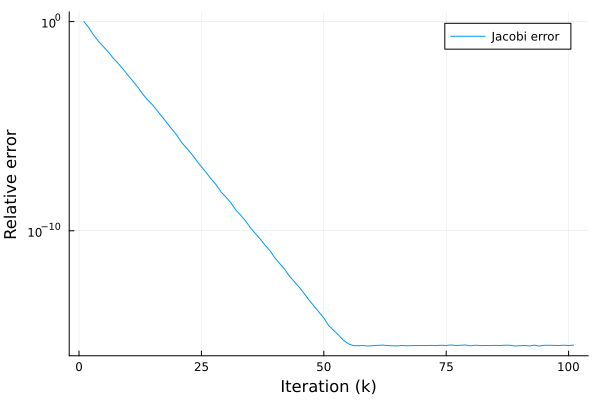

In [5]:
plot(1:N+1,errs,yscale=:log10,label="Jacobi error",xaxis="Iteration (k)", yaxis="Relative error")

## Convergence of Jacobi Method

::: {.callout-warning icon=false}
## Theorem: Jacobi convergence
If $\mathbf{A}$ is strictly diagonally dominant, then Jacobi's method converges for any initial guess $\mathbf{x}^{(0)}$.
:::

. . .

To prove this theorem, we need Gershgorin's disc theorem.

::: {.callout-warning icon=false}
## Theorem: Gershgorin's disc theorem
All eigenvalues of the matrix $\mathbf{M}$ lie in $\cup_{i=1}^n \mathcal{D}_i$ where $\mathcal{D}_i := \{z \in \mathbb{C}: |z - \mathbf{M}_{ii}| \le \sum_{j\not= i}|\mathbf{M}_{ij}|\}$.
:::

. . .

<details><summary>Proof of Jacobi convergence:</summary> 

Note that the diagonal entries of $-\mathbf{D}(\mathbf{A})^{-1} [\mathbf{L}(\mathbf{A}) + \mathbf{U}(\mathbf{A})]$ are zero, and the off diagonal entries are $|\mathbf{A}_{ij}|/|\mathbf{A}_{ii}|$.  Thus, Gershgorin's disc theorem says that all eigenvalues of $-\mathbf{D}(\mathbf{A})^{-1} [\mathbf{L}(\mathbf{A}) + \mathbf{U}(\mathbf{A})]$ have magnitude less than or equal to $\sum_{j\not= i} |\mathbf{A}_{ij}|/|\mathbf{A}_{ii}| < 1$.  Thus, $\rho(-\mathbf{D}(\mathbf{A})^{-1} [\mathbf{L}(\mathbf{A}) + \mathbf{U}(\mathbf{A})]) < 1$, and we have that Jacobi's method converges.
</details>


## Gauss-Seidel method

We can possibly improve Jacobi's method by taking a second look at the equation $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1\\j\not= i}^n (-A_{ij}x_j^{(k-1)}) + b_i \right] \text{ for } i=1, \cdots, n.$$

. . .

If we think about doing the updates to the entries of $\mathbf{x}^{(k)}$ sequentially, we see that we update $x^{(k)}_1$ before updating $x^{(k)}_2$, but in the update of $x^{(k)}_2$, we use $x^{(k-1)}_1$, despite having the (likely better) estimate for the first entry computed in $x^{(k)}_1$.  

. . .

This motivates using the most up-to-date estimates available in this update: $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1}^{i-1} (-A_{ij}x_j^{(k)}) \sum_{j = i+1}^{n} (-A_{ij}x_j^{(k-1)})+ b_i \right] \text{ for } i=1, \cdots, n.$$

---

::: {.callout-caution icon=false}
## Exercise: Sketch the Gauss-Seidel method
Sketch two iterations of the Gauss-Seidel method applied to the system visualized below with the given initial iterate, $\mathbf{x}^{(0)}$.
:::
<details><summary>System:</summary> 

![](figs/system_empty.png){height=300}
</details>

<details><summary>Answer:</summary> 

![](figs/gs_steps.png){height=300}
</details>

## Splitting method form of G-S update

In the same way we did for Jacobi, we can succinctly write the Gauss-Seidel update in matrix-vector form.  

. . .

Noting, now, that the update $$x_i^{(k)} = \frac{1}{A_{ii}} \left[ \sum_{j = 1}^{i-1} (-A_{ij}x_j^{(k)}) \sum_{j = i+1}^{n} (-A_{ij}x_j^{(k-1)})+ b_i \right] \text{ for } i=1, \cdots, n$$ involves the entire lower triangular part of $\mathbf{A}$ interacting with entries of $\mathbf{x}^{(k)}$, 

. . .

we can rewrite this as $$[\mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A})]\mathbf{x}^{(k)} + \mathbf{U}(\mathbf{A}) \mathbf{x}^{(k-1)} = \mathbf{b}.$$

. . .

Thus, the update is $$\mathbf{x}^{(k)} = -[\mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A})]^{-1} \mathbf{U}(\mathbf{A}) \mathbf{x}^{(k-1)} + [\mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A})]^{-1} \mathbf{b}.$$

## Convergence of Gauss-Seidel Method

::: {.callout-warning icon=false}
## Theorem: Gauss-Seidel convergence
If $\mathbf{A}$ is symmetric positive definite, then the Gauss-Seidel method converges for any initial guess $\mathbf{x}^{(0)}$.
:::

. . .

To prove this theorem, we need the Householder-John theorem.

::: {.callout-warning icon=false}
## Theorem: Householder-John theorem
If the real matrices $\mathbf{A}$ and $\mathbf{A}-\mathbf{B}-\mathbf{B}^\top$ are both symmetric positive definite, and $\mathbf{B}$ is real, then the spectral radius of $$\mathbf{H} = (\mathbf{A}-\mathbf{B})^{-1}\mathbf{B}$$ satisfies $\rho(\mathbf{H}) < 1$.
:::

. . .

<details><summary>Proof of Gauss-Seidel convergence:</summary> 

If $\mathbf{A}$ is symmetric, then $\mathbf{L}(\mathbf{A}) = \mathbf{U}(\mathbf{A})^\top$.  In the Householder-John theorem, choose $\mathbf{A} = \mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A}) + \mathbf{U}(\mathbf{A})$, and $\mathbf{B} = \mathbf{U}(\mathbf{A}) = \mathbf{L}(\mathbf{A})^\top$.  Now, by assumption $\mathbf{A}$ is symmetric positive definite, and thus, so must $\mathbf{A} - \mathbf{B} - \mathbf{B}^\top = \mathbf{D}(\mathbf{A})$ be.  (Why?) Thus, by the Householder-John theorem, we have that $\rho(\mathbf{H}) < 1$ for $\mathbf{H} = (\mathbf{A}-\mathbf{B})^{-1}\mathbf{B} = [\mathbf{D}(\mathbf{A}) + \mathbf{L}(\mathbf{A})]^{-1} \mathbf{U}(\mathbf{A})$, and the Gauss-Seidel method must converge.
</details>

---

::: {.callout-caution icon=false}
## Exercise: Implement the Gauss-Seidel method

Complete the Gauss-Seidel method code below and run this method on the same experimental system above.
:::


In [6]:
"""
    gaussseidel(A,b,x_0,N)

Run N iterations of the Gauss-Seidel method on system Ax=b with initial iterate x_0.
"""
function gaussseidel(A,b,x_0,N,x_true)
    D = Diagonal(A);
    L = tril(A,-1);
    U = triu(A,1);

    x_old = x_0
    errs = zeros(N+1)
    errs[1] = norm(x_old - x_true)/norm(x_true)
    for i in 1:N
        x_new = ############################################### complete this code!
        errs[i+1] = norm(x_new - x_true)/norm(x_true);
        x_old = x_new;
    end
    return x, errs
end

gaussseidel

## Successive over-relaxation (SOR)

Gauss-Seidel already improves on Jacobi by using each coordinate's most up-to-date value as soon as it's available.  A natural next question: once we have the Gauss-Seidel update, could we do even better by moving *further* in that direction — or, if Gauss-Seidel overshoots, by damping the step?

. . .

Write the Gauss-Seidel value for coordinate $i$ as $$x_i^{\text{GS}} = \frac{1}{A_{ii}} \left[ \sum_{j=1}^{i-1}(-A_{ij}x_j^{(k)}) + \sum_{j=i+1}^n (-A_{ij}x_j^{(k-1)}) + b_i \right].$$

. . .

The **successive over-relaxation (SOR)** method introduces a relaxation parameter $\omega > 0$ and takes the new iterate to be a weighted average of the old value $x_i^{(k-1)}$ and the Gauss-Seidel value $x_i^{\text{GS}}$: $$x_i^{(k)} = (1-\omega)\,x_i^{(k-1)} + \omega\, x_i^{\text{GS}}.$$

---

Substituting the Gauss-Seidel expression gives the SOR update $$x_i^{(k)} = (1-\omega)x_i^{(k-1)} + \frac{\omega}{A_{ii}} \left[ \sum_{j=1}^{i-1}(-A_{ij}x_j^{(k)}) + \sum_{j=i+1}^n (-A_{ij}x_j^{(k-1)}) + b_i \right] \text{ for } i=1,\cdots,n.$$

[Notice that $\omega = 1$ recovers Gauss-Seidel exactly.  Taking $\omega > 1$ is called **over-relaxation** (we push past the Gauss-Seidel point, hoping to accelerate convergence), while $0 < \omega < 1$ is **under-relaxation** (we damp the step, which can help stabilize an otherwise oscillatory iteration).]{.content-hidden when-format='revealjs' when-format='pptx'}

---

## Splitting method form of SOR update

As with Jacobi and Gauss-Seidel, we can collect the SOR update into matrix-vector form.

. . .

Multiplying through by $A_{ii}$ and separating known ($k-1$) from unknown ($k$) terms, the update becomes $$[\mathbf{D}(\mathbf{A}) + \omega\mathbf{L}(\mathbf{A})]\mathbf{x}^{(k)} = [(1-\omega)\mathbf{D}(\mathbf{A}) - \omega\mathbf{U}(\mathbf{A})]\mathbf{x}^{(k-1)} + \omega\mathbf{b}.$$

. . .

Thus, the update is $$\mathbf{x}^{(k)} = [\mathbf{D}(\mathbf{A}) + \omega\mathbf{L}(\mathbf{A})]^{-1}[(1-\omega)\mathbf{D}(\mathbf{A}) - \omega\mathbf{U}(\mathbf{A})] \mathbf{x}^{(k-1)} + \omega[\mathbf{D}(\mathbf{A}) + \omega\mathbf{L}(\mathbf{A})]^{-1} \mathbf{b}.$$

[When $\omega = 1$ this is exactly the Gauss-Seidel splitting from before.]{.content-hidden when-format='revealjs' when-format='pptx'}

## Convergence of SOR

::: {.callout-warning icon=false}
## Theorem: SOR convergence
If $\mathbf{A}$ is symmetric positive definite, then the SOR method converges for any initial guess $\mathbf{x}^{(0)}$ if and only if $0 < \omega < 2$.
:::

. . .

In order to optimize performance, one would hope to choose the optimal value $\omega$.  This is difficult, but in certain situations one can exactly evaluate the spectral radius of the SOR update matrix in terms of the spectral radius of the Jacobi update matrix, and thus choose the optimal $\omega$.

## Kaczmarz method

The Jacobi and Gauss-Seidel methods update using individual coordinate direction updates onto the hyperplanes defined by the individual equations.  This is not the only way that the iterates can move towards these hyperplanes!

. . .

Perhaps the most natural updating strategy is to project each iterate onto a hyperplane to produce the subsequent iterate.  This strategy is known as the *Kaczmarz method*.  Note that this method is not a splitting method -- it is a different, and common type of method -- a **projection method**!

![](figs/kaczmarz_steps.png){height=150}

. . .

The update for this type of method is given by $\mathbf{x}^{(k)} = \mathbf{x}^{(k-1)} + \frac{b_i - \mathbf{a}_i^\top \mathbf{x}^{(k-1)}}{\|\mathbf{a}_i\|^2} \mathbf{a}_i$ where $\mathbf{a}_i$ is the $i$th row of $\mathbf{A}$ and $i$ is chosen from $1, \cdots, n$.

##

::: {.callout-caution icon=false}
## Exercise: Decreasing error
If $\mathbf{x}^*$ satisfies $\mathbf{A}\mathbf{x}^* = \mathbf{b}$, then $$\|\mathbf{x}^{(k)} - \mathbf{x}^*\|_2 \le \|\mathbf{x}^{(k-1)} - \mathbf{x}^*\|_2.$$  Show that this is true!
:::

<details><summary>Answer:</summary> 
Note that $\mathbf{x}^*$ lies in the intersection of all hyperplane solution sets, and the three vector $\mathbf{x}^{(k)} - \mathbf{x}^*$, $\mathbf{x}^{(k-1)} - \mathbf{x}^*$, and $\mathbf{x}^{(k)} - \mathbf{x}^{(k-1)}$ form the edges of a right triangle.  By the Pythagorean theorem, we have $$\|\mathbf{x}^{(k-1)} - \mathbf{x}^*\|^2 = \|\mathbf{x}^{(k)} - \mathbf{x}^*\|^2 + \|\mathbf{x}^{(k)} - \mathbf{x}^{(k-1)}\|^2.$$  The result follows since $\|\mathbf{x}^{(k)} - \mathbf{x}^{(k-1)}\|^2 \ge 0$.  
</details>